In [1]:
import subprocess
import mph
import comsol.helmholtz_pw_scattering as hlz_pw
import comsol.helmholtz_sw_scattering as hlz_sw

import matplotlib.pyplot as plt

In [2]:
process = subprocess.Popen(
    ["/Applications/COMSOL62/Multiphysics/bin/comsol", "mphserver"]
)

In [3]:
client = mph.Client(port=2036)

COMSOL Multiphysics server 6.2 (Build: 339) started listening on port 2036
Use the console command 'close' to exit the program
2025-11-09 13:47:15 A COMSOL API client with username 'mac' has logged in from 'Macs-MacBook-Air-2.local'


### PW

In [4]:
parameters_pw = hlz_pw.ModelParameters()

In [5]:
model_pw = hlz_pw.create_new_model(client, parameters_pw)

In [6]:
model_pw.solve()

### SW

In [7]:
parameters_sw = hlz_sw.ModelParameters()

In [8]:
model_sw = hlz_sw.create_new_model(client, parameters_sw)

In [9]:
model_sw.solve()

### Processing

In [13]:
freq = model_pw.evaluate("freq", "Hz")
sigma_pw = model_pw.evaluate("point_ot")
sigma_sw = model_sw.evaluate("point_ot")

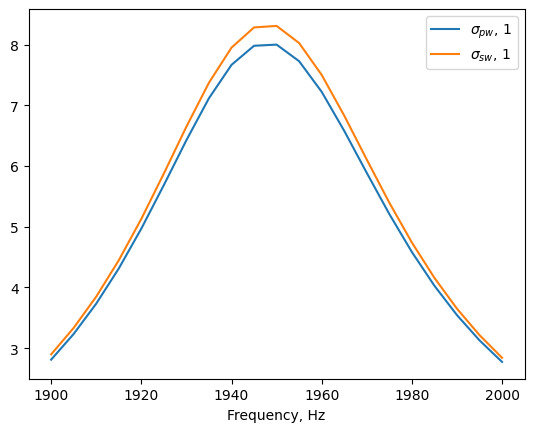

In [15]:
plt.plot(freq, sigma_pw, label="$\\sigma_{pw}$, 1")
plt.plot(freq, sigma_sw, label="$\\sigma_{sw}$, 1")
plt.legend()
plt.xlabel("Frequency, Hz")
plt.show()

In [16]:
model_sw.clear()
model_sw.save()

In [17]:
client.disconnect()

2025-11-09 13:56:44 A COMSOL API client with username 'mac' logged in from 'Macs-MacBook-Air-2.local' has disconnected


In [18]:
process.terminate()